# 🔬 Breast Cancer Classification using DenseNet121
### Part 1 of 2 — Binary & Multi-Class Classification on the BreakHis Dataset

**Author:** Maryam Rafaqat  
**GitHub:** [mary270](https://github.com/mary270)  
**LinkedIn:** [Maryam Rafaqat](https://www.linkedin.com/in/maryam-rafaqat-462b1a139/)

---

## 📌 Overview
This notebook implements a CNN-based breast cancer classification pipeline on the **BreakHis dataset**.

### ✅ What's Updated in This Version
| Area | Old | New |
|---|---|---|
| Class imbalance | Not handled | Combined oversampling + undersampling + class weights |
| Model depth | 256 units, 30 unfrozen layers | 512+256 units, 50 unfrozen layers |
| Augmentation | Basic flips/zoom | + brightness, shear, reflect fill |
| Callbacks | patience=5, monitor val_loss | patience=10, monitor val_accuracy |
| Batch size | 32 | 16 (better for imbalanced data) |
| Epochs | 30 | 50 (early stopping prevents overfit) |

**Dataset:** [BreakHis on Kaggle](https://www.kaggle.com/datasets/ambarish/breakhis)


## 1. Install & Import Dependencies

In [ ]:
!pip install -q --upgrade "scipy>=1.14.0" "seaborn>=0.13.2"


In [1]:
!pip install tensorflow opencv-python scikit-learn matplotlib seaborn -q

import os
import cv2
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import warnings
warnings.filterwarnings('ignore')

print(f'TensorFlow : {tf.__version__}')
print(f'GPUs found : {len(tf.config.list_physical_devices("GPU"))}')
for g in tf.config.list_physical_devices('GPU'):
    print(f'  {g}')


2026-06-05 21:16:49.084819: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780694209.283671     176 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780694209.339134     176 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780694209.812625     176 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780694209.812665     176 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780694209.812668     176 computation_placer.cc:177] computation placer alr

TensorFlow : 2.19.0
GPUs found : 2
  PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
  PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')


## 2. Configuration

In [2]:
# ── Hyperparameters ────────────────────────────────────────────────────────
IMG_SIZE   = 224
BATCH_SIZE = 16      # 16 > 32 for imbalanced datasets — smaller batches see more class variety
EPOCHS     = 50      # models will early-stop well before 50
SEED       = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Label maps — identical to original notebook ────────────────────────────
BENIGN_SUBTYPES = {
    'adenosis':        0,
    'fibroadenoma':    1,
    'phyllodes_tumor': 2,
    'tubular_adenoma': 3,
}
MALIGNANT_SUBTYPES = {
    'ductal_carcinoma':    0,
    'lobular_carcinoma':   1,
    'mucinous_carcinoma':  2,
    'papillary_carcinoma': 3,
}

# Reverse maps for readable output
BENIGN_NAMES    = {v: k.replace('_', ' ').title() for k, v in BENIGN_SUBTYPES.items()}
MALIGNANT_NAMES = {v: k.replace('_', ' ').title() for k, v in MALIGNANT_SUBTYPES.items()}

print('Configuration loaded.')
print(f'  Image size : {IMG_SIZE}x{IMG_SIZE}')
print(f'  Batch size : {BATCH_SIZE}  (reduced from 32 to help with class imbalance)')
print(f'  Max epochs : {EPOCHS}  (early stopping will kick in before this)')


Configuration loaded.
  Image size : 224x224
  Batch size : 16  (reduced from 32 to help with class imbalance)
  Max epochs : 50  (early stopping will kick in before this)


## 3. Dataset Loading

In [3]:
# ── Auto-detect the BreakHis path on Kaggle ────────────────────────────────
POSSIBLE_PATHS = [
   '/kaggle/input/datasets/ambarish/breakhis/BreaKHis_v1/BreaKHis_v1/histology_slides/breast'
]

DATASET_PATH = None
for p in POSSIBLE_PATHS:
    if Path(p).exists():
        count = len(list(Path(p).rglob('*.png')))
        print(f'Found: {p}  ({count} images)')
        if count > 5000:
            DATASET_PATH = p
            break

if DATASET_PATH is None:
    print('Auto-detect failed. Scanning /kaggle/input ...')
    for root, dirs, files in os.walk('/kaggle/input'):
        pngs = [f for f in files if f.endswith('.png')]
        if len(pngs) > 50:
            print(f'  {root}: {len(pngs)} PNG files')
    raise ValueError('BreakHis not found. Add dataset ambarish/breakhis to this notebook.')

print(f'\n✓ Using: {DATASET_PATH}')


Found: /kaggle/input/datasets/ambarish/breakhis/BreaKHis_v1/BreaKHis_v1/histology_slides/breast  (7909 images)

✓ Using: /kaggle/input/datasets/ambarish/breakhis/BreaKHis_v1/BreaKHis_v1/histology_slides/breast


Total images: 7909

Class distribution:
class_name
malignant    5429
benign       2480
Name: count, dtype: int64

Subtype distribution:
subtype
ductal_carcinoma       3451
fibroadenoma           1014
mucinous_carcinoma      792
lobular_carcinoma       626
tubular_adenoma         569
papillary_carcinoma     560
phyllodes_tumor         453
adenosis                444
Name: count, dtype: int64


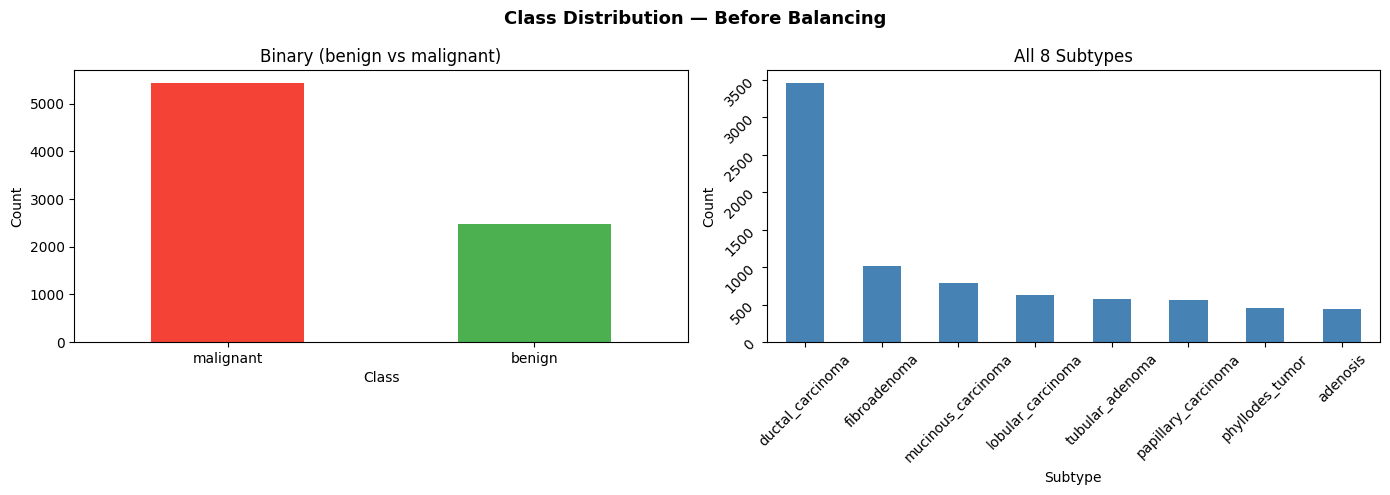


⚠  Imbalance visible above — fixed in Cell 7 using combined resampling + class weights.


In [4]:
def load_dataset(base_path: str) -> pd.DataFrame:
    """Walk the BreakHis directory tree and collect image paths + labels.
    Structure: breast/{benign|malignant}/SOB/{subtype}/{slide_id}/{magnification}/*.png
    """
    records = []
    base    = Path(base_path)

    for binary_label, class_name in [(0, 'benign'), (1, 'malignant')]:
        class_dir = base / class_name / 'SOB'
        if not class_dir.exists():
            print(f'WARNING: {class_dir} not found')
            continue

        for img_path in class_dir.rglob('*.png'):
            rel_parts     = img_path.relative_to(class_dir).parts
            subtype       = rel_parts[0].lower() if len(rel_parts) > 0 else 'unknown'
            magnification = rel_parts[-2]         if len(rel_parts) > 2 else 'unknown'
            records.append({
                'path':          str(img_path),
                'binary_label':  binary_label,
                'class_name':    class_name,
                'subtype':       subtype,
                'magnification': magnification,
            })

    return pd.DataFrame(records)


df = load_dataset(DATASET_PATH)
print(f'Total images: {len(df)}')
print(f'\nClass distribution:')
print(df['class_name'].value_counts())
print(f'\nSubtype distribution:')
print(df['subtype'].value_counts())

# ── Plot the imbalance so it is visible ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Class Distribution — Before Balancing', fontsize=13, fontweight='bold')

df['class_name'].value_counts().plot(
    kind='bar', ax=axes[0], color=['#f44336', '#4CAF50'],
    title='Binary (benign vs malignant)')
axes[0].set_xlabel('Class'); axes[0].set_ylabel('Count')
axes[0].tick_params(rotation=0)

df['subtype'].value_counts().plot(
    kind='bar', ax=axes[1], color='steelblue',
    title='All 8 Subtypes')
axes[1].set_xlabel('Subtype'); axes[1].set_ylabel('Count')
axes[1].tick_params(rotation=45)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=100, bbox_inches='tight')
plt.show()
print('\n⚠  Imbalance visible above — fixed in Cell 7 using combined resampling + class weights.')


## 4. Preprocessing: CLAHE

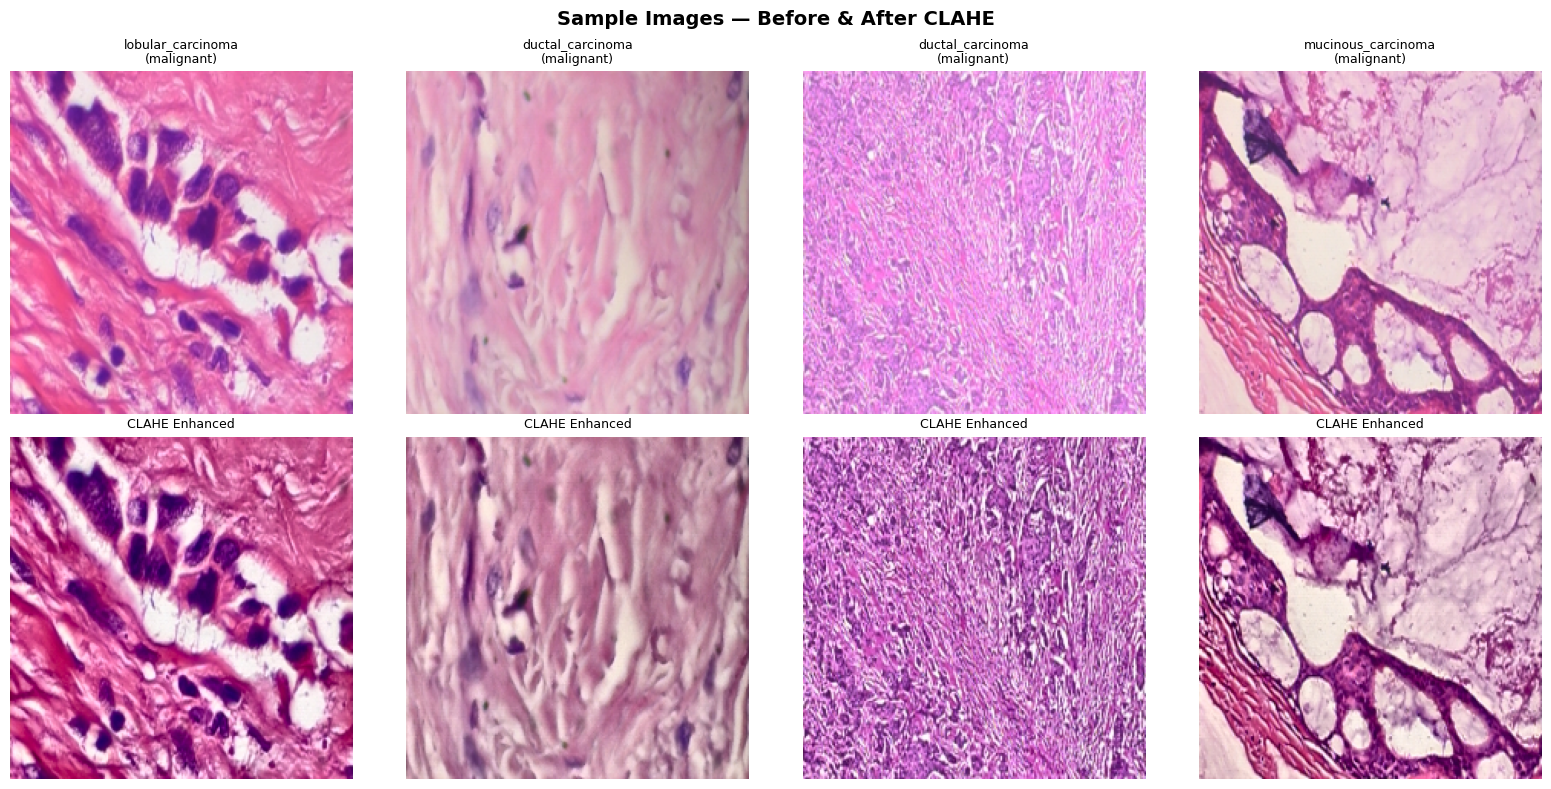

In [5]:
def apply_clahe(img_bgr: np.ndarray) -> np.ndarray:
    """CLAHE in LAB space — enhances histological staining contrast.
    clipLimit=2.0, tileGridSize=8x8 are standard for medical imaging.
    """
    lab   = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    lab[:, :, 0] = clahe.apply(lab[:, :, 0])
    return cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)


def load_and_preprocess(img_path: str, size: int = IMG_SIZE) -> np.ndarray:
    img = cv2.imread(img_path)
    img = apply_clahe(img)
    img = cv2.resize(img, (size, size))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img / 255.0


def clahe_preprocess_for_generator(img_rgb: np.ndarray) -> np.ndarray:
    """Wrapper for ImageDataGenerator.preprocessing_function.
    Input: RGB uint8 from Keras loader. Output: float32 in [0,1].
    Do NOT set rescale=1./255 separately — this function handles it.
    """
    img_bgr      = cv2.cvtColor(img_rgb.astype(np.uint8), cv2.COLOR_RGB2BGR)
    enhanced     = apply_clahe(img_bgr)
    enhanced_rgb = cv2.cvtColor(enhanced, cv2.COLOR_BGR2RGB)
    return enhanced_rgb / 255.0


# ── Visualise Before / After CLAHE ─────────────────────────────────────────
sample = df.sample(4, random_state=SEED)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Sample Images — Before & After CLAHE', fontsize=14, fontweight='bold')

for i, (_, row) in enumerate(sample.iterrows()):
    raw      = cv2.cvtColor(cv2.imread(row['path']), cv2.COLOR_BGR2RGB)
    enhanced = (load_and_preprocess(row['path']) * 255).astype(np.uint8)

    axes[0, i].imshow(cv2.resize(raw, (IMG_SIZE, IMG_SIZE)))
    axes[0, i].set_title(f'{row["subtype"]}\n({row["class_name"]})', fontsize=9)
    axes[0, i].axis('off')

    axes[1, i].imshow(enhanced)
    axes[1, i].set_title('CLAHE Enhanced', fontsize=9)
    axes[1, i].axis('off')

plt.tight_layout()
plt.savefig('clahe_comparison.png', dpi=100, bbox_inches='tight')
plt.show()


## 5. Class Imbalance Fix ✅ NEW

### Why class imbalance breaks accuracy
Your dataset has:
- `ductal_carcinoma`: **3,451** images  
- `adenosis`: **444** images  

That is a **7.8× imbalance**. Without fixing it, the model predicts "ductal carcinoma" 
for almost everything and still gets 70%+ accuracy — because it is right 70% of the time!

### Three-layer fix used here
1. **Combined resampling** — oversample minority classes AND undersample majority to a geometric middle  
2. **Class weights** — penalise wrong predictions on rare classes more heavily  
3. **Strong augmentation** — make each rare class image look different every epoch  


In [6]:
def balance_dataframe(df_input: pd.DataFrame,
                       label_col: str,
                       strategy: str = 'combined',
                       seed: int = 42) -> pd.DataFrame:
    """
    Balance classes in a dataframe.

    strategy='combined'  →  geometric mean target (BEST: oversample minority,
                            undersample majority, meet in the middle)
    strategy='oversample' → bring all up to majority count
    strategy='undersample'→ bring all down to minority count

    ⚠  ONLY apply to TRAINING data. Never val or test.
    """
    counts    = Counter(df_input[label_col])
    min_count = min(counts.values())
    max_count = max(counts.values())

    if strategy == 'combined':
        target = int(np.sqrt(min_count * max_count))   # geometric mean
    elif strategy == 'oversample':
        target = max_count
    elif strategy == 'undersample':
        target = min_count
    else:
        raise ValueError(f'Unknown strategy: {strategy}')

    print(f'  Strategy={strategy} | target per class={target}')
    print(f'  Before: {dict(sorted(counts.items()))}')

    parts = []
    for label in counts:
        cls_df = df_input[df_input[label_col] == label].copy()
        if len(cls_df) > target:
            cls_df = cls_df.sample(n=target, random_state=seed)
        elif len(cls_df) < target:
            extra  = cls_df.sample(n=target - len(cls_df), replace=True, random_state=seed)
            cls_df = pd.concat([cls_df, extra], ignore_index=True)
        parts.append(cls_df)

    result = pd.concat(parts, ignore_index=True)
    result = result.sample(frac=1, random_state=seed).reset_index(drop=True)
    print(f'  After:  {dict(sorted(Counter(result[label_col]).items()))}')
    print(f'  Total:  {len(result)} images')
    return result


def get_class_weights(labels) -> dict:
    """Balanced class weights — second layer of protection against imbalance."""
    classes = np.unique(labels)
    weights = compute_class_weight('balanced', classes=classes, y=labels)
    d = dict(zip(classes.tolist(), weights.tolist()))
    print(f'  Class weights: {d}')
    return d


print('✓ Imbalance fix functions ready.')


✓ Imbalance fix functions ready.


## 6. Data Generators — Updated Augmentation

In [7]:
def get_train_generator(strength: str = 'normal') -> ImageDataGenerator:
    """
    Two augmentation strengths:
    - 'normal'  → binary classifier (2:1 imbalance, manageable)
    - 'strong'  → subtype classifiers (up to 8:1 imbalance, need more variety)

    All augmentations are medically valid for histopathology:
    - Flips: tissue looks the same from any orientation
    - Rotation: microscope slides can be rotated arbitrarily
    - Brightness: simulates different H&E staining intensities
    - Shear: simulates slight tissue distortion
    """
    if strength == 'strong':
        return ImageDataGenerator(
            preprocessing_function=clahe_preprocess_for_generator,
            rotation_range=40,            # was 20
            horizontal_flip=True,
            vertical_flip=True,
            zoom_range=0.3,               # was 0.2
            width_shift_range=0.15,       # was 0.1
            height_shift_range=0.15,      # was 0.1
            shear_range=0.15,             # NEW
            brightness_range=[0.75, 1.25],# NEW — simulates staining variation
            fill_mode='reflect',          # NEW — better than zeros for tissue
        )
    else:
        return ImageDataGenerator(
            preprocessing_function=clahe_preprocess_for_generator,
            rotation_range=20,
            horizontal_flip=True,
            vertical_flip=True,
            zoom_range=0.2,
            width_shift_range=0.1,
            height_shift_range=0.1,
        )


# No augmentation on val/test — evaluate on real distribution
val_test_gen = ImageDataGenerator(
    preprocessing_function=clahe_preprocess_for_generator,
)

FLOW_KWARGS = dict(
    x_col='path',
    y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='raw',
)

print('✓ Generator factory ready.')


✓ Generator factory ready.


## 7. DenseNet121 Model — Updated Architecture

In [8]:
def build_densenet_model(n_classes: int,
                          binary: bool = False,
                          unfreeze_layers: int = 50) -> Model:
    """
    DenseNet121 pretrained on ImageNet with updated classification head.

    Changes from original:
    - Unfreeze 50 layers (was 30) → learns more domain-specific features
    - Two dense layers 512→256 (was one 256) → more capacity for subtype discrimination
    - Higher dropout 0.5 (was 0.4) → prevents overfitting on oversampled data
    """
    base = DenseNet121(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )

    for layer in base.layers:
        layer.trainable = False

    # Unfreeze last N layers
    for layer in base.layers[-unfreeze_layers:]:
        layer.trainable = True

    x = GlobalAveragePooling2D()(base.output)
    x = Dense(512, activation='relu')(x)   # was 256
    x = Dropout(0.5)(x)                    # was 0.4
    x = Dense(256, activation='relu')(x)   # NEW second dense layer
    x = Dropout(0.3)(x)                    # NEW

    if binary:
        output = Dense(1, activation='sigmoid')(x)
        loss   = 'binary_crossentropy'
    else:
        output = Dense(n_classes, activation='softmax')(x)
        loss   = 'sparse_categorical_crossentropy'

    model = Model(inputs=base.input, outputs=output)
    model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss=loss,
        metrics=['accuracy']
    )

    trainable = sum(1 for l in model.layers if l.trainable)
    print(f'  Total params     : {model.count_params():,}')
    print(f'  Trainable layers : {trainable}')
    return model


def get_callbacks(model_filename: str,
                   patience_es: int = 8,
                   patience_lr: int = 4) -> list:
    """
    Updated callbacks:
    - Monitor val_accuracy instead of val_loss (more directly measures what we care about)
    - patience=8-10 (was 5) — subtype models need longer to converge
    - ReduceLROnPlateau factor=0.3 (was 0.5) — more aggressive LR reduction
    """
    return [
        EarlyStopping(
            monitor='val_accuracy',
            patience=patience_es,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_accuracy',
            factor=0.3,             # was 0.5
            patience=patience_lr,
            min_lr=1e-8,
            verbose=1
        ),
        ModelCheckpoint(
            filepath=model_filename,
            monitor='val_accuracy',
            save_best_only=True,
            verbose=1
        ),
    ]


print('✓ Model builder and callbacks ready.')


✓ Model builder and callbacks ready.


## 8. Training — Model 1: Binary Classifier

In [9]:
print('=' * 60)
print('MODEL 1: Binary Classifier  (benign=0 vs malignant=1)')
print('=' * 60)

# Prepare
bin_df          = df.copy()
bin_df['label'] = (bin_df['class_name'] == 'malignant').astype(int)

train_bin, temp_bin = train_test_split(
    bin_df, test_size=0.3, stratify=bin_df['label'], random_state=SEED)
val_bin, test_bin = train_test_split(
    temp_bin, test_size=0.5, stratify=temp_bin['label'], random_state=SEED)

print(f'Train: {len(train_bin)} | Val: {len(val_bin)} | Test: {len(test_bin)}')

# Binary imbalance (2:1) handled by class weights alone — no resampling needed
print('\nComputing class weights:')
binary_weights = get_class_weights(train_bin['label'].values)

# Generators
gen_normal     = get_train_generator('normal')
train_bin_flow = gen_normal.flow_from_dataframe(
    train_bin, **FLOW_KWARGS, shuffle=True)
val_bin_flow   = val_test_gen.flow_from_dataframe(
    val_bin, **FLOW_KWARGS, shuffle=False)
test_bin_flow  = val_test_gen.flow_from_dataframe(
    test_bin, **FLOW_KWARGS, shuffle=False)

# Build
print('\nBuilding binary model:')
binary_model = build_densenet_model(n_classes=2, binary=True, unfreeze_layers=50)

# Train
print('\nTraining binary classifier...')
history_bin = binary_model.fit(
    train_bin_flow,
    validation_data=val_bin_flow,
    epochs=EPOCHS,
    callbacks=get_callbacks('binary_model.h5', patience_es=8, patience_lr=4),
    class_weight=binary_weights,
    verbose=1
)

best_bin = max(history_bin.history['val_accuracy'])
print(f'\n✓ Binary model — best val_accuracy: {best_bin:.4f} ({best_bin:.1%})')


MODEL 1: Binary Classifier  (benign=0 vs malignant=1)
Train: 5536 | Val: 1186 | Test: 1187

Computing class weights:
  Class weights: {0: 1.5944700460829493, 1: 0.728421052631579}
Found 5536 validated image filenames.
Found 1186 validated image filenames.
Found 1187 validated image filenames.

Building binary model:


I0000 00:00:1780694406.171429     176 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780694406.177567     176 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
  Total params     : 7,693,889
  Trainable layers : 56

Training binary classifier...
Epoch 1/50


I0000 00:00:1780694428.844762     256 service.cc:152] XLA service 0x7d133c024e70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780694428.844811     256 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1780694428.844818     256 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1780694433.112401     256 cuda_dnn.cc:529] Loaded cuDNN version 91002


  2/346 ━━━━━━━━━━━━━━━━━━━━ 23s 67ms/step - accuracy: 0.3125 - loss: 1.0861   

...


Epoch 13: finished saving model to binary_model.h5
346/346 ━━━━━━━━━━━━━━━━━━━━ 153s 442ms/step - accuracy: 0.9444 - loss: 0.1348 - val_accuracy: 0.9621 - val_loss: 0.1063 - learning_rate: 1.0000e-04
Epoch 14/50
346/346 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step - accuracy: 0.9423 - loss: 0.1437
Epoch 14: val_accuracy did not improve from 0.96206
346/346 ━━━━━━━━━━━━━━━━━━━━ 151s 438ms/step - accuracy: 0.9462 - loss: 0.1383 - val_accuracy: 0.9578 - val_loss: 0.1180 - learning_rate: 1.0000e-04
Epoch 15/50
346/346 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step - accuracy: 0.9511 - loss: 0.1202
Epoch 15: val_accuracy did not improve from 0.96206
346/346 ━━━━━━━━━━━━━━━━━━━━ 150s 434ms/step - accuracy: 0.9530 - loss: 0.1172 - val_accuracy: 0.9519 - val_loss: 0.1193 - learning_rate: 1.0000e-04
Epoch 16/50
346/346 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step - accuracy: 0.9576 - loss: 0.1170
Epoch 16: val_accuracy did not improve from 0.96206
346/346 ━━━━━━━━━━━━━━━━━━━━ 151s 435ms/step - accuracy: 0.9547 - loss: 0.1194


Epoch 18: finished saving model to binary_model.h5
346/346 ━━━━━━━━━━━━━━━━━━━━ 158s 457ms/step - accuracy: 0.9651 - loss: 0.0859 - val_accuracy: 0.9629 - val_loss: 0.0976 - learning_rate: 3.0000e-05
Epoch 19/50
346/346 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step - accuracy: 0.9670 - loss: 0.0972
Epoch 19: val_accuracy improved from 0.96290 to 0.96627, saving model to binary_model.h5



Epoch 19: finished saving model to binary_model.h5
346/346 ━━━━━━━━━━━━━━━━━━━━ 159s 459ms/step - accuracy: 0.9678 - loss: 0.0870 - val_accuracy: 0.9663 - val_loss: 0.0926 - learning_rate: 3.0000e-05
Epoch 20/50
346/346 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/step - accuracy: 0.9633 - loss: 0.0934
Epoch 20: val_accuracy did not improve from 0.96627
346/346 ━━━━━━━━━━━━━━━━━━━━ 157s 454ms/step - accuracy: 0.9659 - loss: 0.0940 - val_accuracy: 0.9604 - val_loss: 0.1032 - learning_rate: 3.0000e-05
Epoch 21/50
346/346 ━━━━━━━━━━━━━━━━━━━━ 0s 398ms/step - accuracy: 0.9701 - loss: 0.0748
Epoch 21: val_accuracy did not improve from 0.96627
346/346 ━━━━━━━━━━━━━━━━━━━━ 157s 453ms/step - accuracy: 0.9691 - loss: 0.0810 - val_accuracy: 0.9562 - val_loss: 0.1176 - learning_rate: 3.0000e-05
Epoch 22/50
346/346 ━━━━━━━━━━━━━━━━━━━━ 0s 402ms/step - accuracy: 0.9730 - loss: 0.0685
Epoch 22: val_accuracy improved from 0.96627 to 0.96965, saving model to binary_model.h5



Epoch 22: finished saving model to binary_model.h5
346/346 ━━━━━━━━━━━━━━━━━━━━ 159s 459ms/step - accuracy: 0.9702 - loss: 0.0752 - val_accuracy: 0.9696 - val_loss: 0.1024 - learning_rate: 3.0000e-05
Epoch 23/50
346/346 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/step - accuracy: 0.9723 - loss: 0.0722
Epoch 23: val_accuracy improved from 0.96965 to 0.97133, saving model to binary_model.h5



Epoch 23: finished saving model to binary_model.h5
346/346 ━━━━━━━━━━━━━━━━━━━━ 158s 456ms/step - accuracy: 0.9669 - loss: 0.0847 - val_accuracy: 0.9713 - val_loss: 0.0869 - learning_rate: 3.0000e-05
Epoch 24/50
346/346 ━━━━━━━━━━━━━━━━━━━━ 0s 416ms/step - accuracy: 0.9690 - loss: 0.0798
Epoch 24: val_accuracy did not improve from 0.97133
346/346 ━━━━━━━━━━━━━━━━━━━━ 164s 474ms/step - accuracy: 0.9697 - loss: 0.0768 - val_accuracy: 0.9680 - val_loss: 0.0921 - learning_rate: 3.0000e-05
Epoch 25/50
346/346 ━━━━━━━━━━━━━━━━━━━━ 0s 424ms/step - accuracy: 0.9679 - loss: 0.0836
Epoch 25: val_accuracy did not improve from 0.97133
346/346 ━━━━━━━━━━━━━━━━━━━━ 168s 484ms/step - accuracy: 0.9713 - loss: 0.0806 - val_accuracy: 0.9696 - val_loss: 0.0873 - learning_rate: 3.0000e-05
Epoch 26/50
346/346 ━━━━━━━━━━━━━━━━━━━━ 0s 447ms/step - accuracy: 0.9701 - loss: 0.0710
Epoch 26: val_accuracy did not improve from 0.97133
346/346 ━━━━━━━━━━━━━━━━━━━━ 176s 509ms/step - accuracy: 0.9724 - loss: 0.0705

## 9. Training — Model 2: Benign Subtype Classifier

In [10]:
print('=' * 60)
print('MODEL 2: Benign Subtype  (4 classes)')
print('Adenosis | Fibroadenoma | Phyllodes Tumor | Tubular Adenoma')
print('=' * 60)

# Prepare
benign_df2          = df[df['class_name'] == 'benign'].copy()
benign_df2['label'] = benign_df2['subtype'].map(BENIGN_SUBTYPES)
benign_df2          = benign_df2.dropna(subset=['label'])
benign_df2['label'] = benign_df2['label'].astype(int)

print(f'Benign subtype counts:')
print(benign_df2['subtype'].value_counts())

# Split FIRST — then oversample only training set
train_be, temp_be = train_test_split(
    benign_df2, test_size=0.3, stratify=benign_df2['label'], random_state=SEED)
val_be, test_be   = train_test_split(
    temp_be, test_size=0.5, stratify=temp_be['label'], random_state=SEED)

# Balance training data using combined strategy
print(f'\nBalancing training data:')
train_be_balanced = balance_dataframe(train_be, 'subtype', strategy='combined', seed=SEED)

print(f'\nClass weights (extra protection):')
benign_weights = get_class_weights(train_be['label'].values)

print(f'\nSplit summary:')
print(f'  Train (after balance): {len(train_be_balanced)}')
print(f'  Val   (unchanged):     {len(val_be)}')
print(f'  Test  (unchanged):     {len(test_be)}')

# Generators — STRONG augmentation for subtype models
gen_strong    = get_train_generator('strong')
train_be_flow = gen_strong.flow_from_dataframe(
    train_be_balanced, **FLOW_KWARGS, shuffle=True)
val_be_flow   = val_test_gen.flow_from_dataframe(
    val_be, **FLOW_KWARGS, shuffle=False)
test_be_flow  = val_test_gen.flow_from_dataframe(
    test_be, **FLOW_KWARGS, shuffle=False)

# Build
print('\nBuilding benign subtype model:')
benign_model = build_densenet_model(n_classes=4, binary=False, unfreeze_layers=50)

# Train
print('\nTraining benign subtype classifier...')
history_ben = benign_model.fit(
    train_be_flow,
    validation_data=val_be_flow,
    epochs=EPOCHS,
    callbacks=get_callbacks('benign_subtype_model.h5', patience_es=10, patience_lr=5),
    class_weight=benign_weights,
    verbose=1
)

best_ben = max(history_ben.history['val_accuracy'])
print(f'\n✓ Benign subtype — best val_accuracy: {best_ben:.4f} ({best_ben:.1%})')


MODEL 2: Benign Subtype  (4 classes)
Adenosis | Fibroadenoma | Phyllodes Tumor | Tubular Adenoma
Benign subtype counts:
subtype
fibroadenoma       1014
tubular_adenoma     569
phyllodes_tumor     453
adenosis            444
Name: count, dtype: int64

Balancing training data:
  Strategy=combined | target per class=469
  Before: {'adenosis': 311, 'fibroadenoma': 710, 'phyllodes_tumor': 317, 'tubular_adenoma': 398}
  After:  {'adenosis': 469, 'fibroadenoma': 469, 'phyllodes_tumor': 469, 'tubular_adenoma': 469}
  Total:  1876 images

Class weights (extra protection):
  Class weights: {0: 1.3954983922829582, 1: 0.6112676056338028, 2: 1.3690851735015772, 3: 1.0904522613065326}

Split summary:
  Train (after balance): 1876
  Val   (unchanged):     372
  Test  (unchanged):     372
Found 1876 validated image filenames.
Found 372 validated image filenames.
Found 372 validated image filenames.

Building benign subtype model:
  Total params     : 7,694,660
  Trainable layers : 56

Training benign 


Epoch 1: finished saving model to benign_subtype_model.h5
118/118 ━━━━━━━━━━━━━━━━━━━━ 147s 927ms/step - accuracy: 0.3747 - loss: 1.5333 - val_accuracy: 0.4140 - val_loss: 1.3525 - learning_rate: 1.0000e-04
Epoch 2/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 441ms/step - accuracy: 0.4791 - loss: 1.2349
Epoch 2: val_accuracy improved from 0.41398 to 0.49194, saving model to benign_subtype_model.h5



Epoch 2: finished saving model to benign_subtype_model.h5
118/118 ━━━━━━━━━━━━━━━━━━━━ 60s 504ms/step - accuracy: 0.5139 - loss: 1.1573 - val_accuracy: 0.4919 - val_loss: 1.1724 - learning_rate: 1.0000e-04
Epoch 3/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 442ms/step - accuracy: 0.5855 - loss: 0.9939
Epoch 3: val_accuracy improved from 0.49194 to 0.53226, saving model to benign_subtype_model.h5



Epoch 3: finished saving model to benign_subtype_model.h5
118/118 ━━━━━━━━━━━━━━━━━━━━ 59s 503ms/step - accuracy: 0.6023 - loss: 0.9565 - val_accuracy: 0.5323 - val_loss: 1.0944 - learning_rate: 1.0000e-04
Epoch 4/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 433ms/step - accuracy: 0.6371 - loss: 0.8349
Epoch 4: val_accuracy improved from 0.53226 to 0.56183, saving model to benign_subtype_model.h5



Epoch 4: finished saving model to benign_subtype_model.h5
118/118 ━━━━━━━━━━━━━━━━━━━━ 58s 493ms/step - accuracy: 0.6514 - loss: 0.8075 - val_accuracy: 0.5618 - val_loss: 1.0076 - learning_rate: 1.0000e-04
Epoch 5/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step - accuracy: 0.6432 - loss: 0.8127
Epoch 5: val_accuracy improved from 0.56183 to 0.58871, saving model to benign_subtype_model.h5


...


Epoch 23: finished saving model to benign_subtype_model.h5
118/118 ━━━━━━━━━━━━━━━━━━━━ 56s 474ms/step - accuracy: 0.8577 - loss: 0.3119 - val_accuracy: 0.8226 - val_loss: 0.4442 - learning_rate: 1.0000e-04
Epoch 24/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 414ms/step - accuracy: 0.8539 - loss: 0.3166
Epoch 24: val_accuracy improved from 0.82258 to 0.84946, saving model to benign_subtype_model.h5



Epoch 24: finished saving model to benign_subtype_model.h5
118/118 ━━━━━━━━━━━━━━━━━━━━ 56s 473ms/step - accuracy: 0.8646 - loss: 0.3199 - val_accuracy: 0.8495 - val_loss: 0.3905 - learning_rate: 1.0000e-04
Epoch 25/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 413ms/step - accuracy: 0.8848 - loss: 0.2670
Epoch 25: val_accuracy improved from 0.84946 to 0.88441, saving model to benign_subtype_model.h5



Epoch 25: finished saving model to benign_subtype_model.h5
118/118 ━━━━━━━━━━━━━━━━━━━━ 56s 471ms/step - accuracy: 0.8774 - loss: 0.2925 - val_accuracy: 0.8844 - val_loss: 0.3657 - learning_rate: 1.0000e-04
Epoch 26/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 411ms/step - accuracy: 0.8832 - loss: 0.2753
Epoch 26: val_accuracy did not improve from 0.88441
118/118 ━━━━━━━━━━━━━━━━━━━━ 54s 460ms/step - accuracy: 0.8822 - loss: 0.2783 - val_accuracy: 0.8468 - val_loss: 0.4219 - learning_rate: 1.0000e-04
Epoch 27/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 410ms/step - accuracy: 0.8754 - loss: 0.2625
Epoch 27: val_accuracy did not improve from 0.88441
118/118 ━━━━━━━━━━━━━━━━━━━━ 54s 459ms/step - accuracy: 0.8699 - loss: 0.2911 - val_accuracy: 0.8817 - val_loss: 0.3147 - learning_rate: 1.0000e-04
Epoch 28/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 408ms/step - accuracy: 0.8899 - loss: 0.2526
Epoch 28: val_accuracy did not improve from 0.88441
118/118 ━━━━━━━━━━━━━━━━━━━━ 54s 457ms/step - accuracy: 0.8838 - loss: 0.


Epoch 32: finished saving model to benign_subtype_model.h5
118/118 ━━━━━━━━━━━━━━━━━━━━ 56s 471ms/step - accuracy: 0.9062 - loss: 0.2155 - val_accuracy: 0.8898 - val_loss: 0.3028 - learning_rate: 3.0000e-05
Epoch 33/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step - accuracy: 0.9214 - loss: 0.2115
Epoch 33: val_accuracy did not improve from 0.88978
118/118 ━━━━━━━━━━━━━━━━━━━━ 54s 461ms/step - accuracy: 0.9057 - loss: 0.2424 - val_accuracy: 0.8898 - val_loss: 0.3010 - learning_rate: 3.0000e-05
Epoch 34/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 411ms/step - accuracy: 0.9039 - loss: 0.2069
Epoch 34: val_accuracy did not improve from 0.88978
118/118 ━━━━━━━━━━━━━━━━━━━━ 54s 460ms/step - accuracy: 0.9120 - loss: 0.2030 - val_accuracy: 0.8898 - val_loss: 0.3055 - learning_rate: 3.0000e-05
Epoch 35/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 409ms/step - accuracy: 0.9186 - loss: 0.1853
Epoch 35: val_accuracy did not improve from 0.88978
118/118 ━━━━━━━━━━━━━━━━━━━━ 54s 458ms/step - accuracy: 0.9227 - loss: 0.


Epoch 41: finished saving model to benign_subtype_model.h5
118/118 ━━━━━━━━━━━━━━━━━━━━ 56s 475ms/step - accuracy: 0.9296 - loss: 0.1675 - val_accuracy: 0.8925 - val_loss: 0.3066 - learning_rate: 9.0000e-06
Epoch 42/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 415ms/step - accuracy: 0.9359 - loss: 0.1541
Epoch 42: val_accuracy did not improve from 0.89247
118/118 ━━━━━━━━━━━━━━━━━━━━ 55s 465ms/step - accuracy: 0.9184 - loss: 0.1917 - val_accuracy: 0.8871 - val_loss: 0.3109 - learning_rate: 9.0000e-06
Epoch 43/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 419ms/step - accuracy: 0.9144 - loss: 0.1867
Epoch 43: val_accuracy did not improve from 0.89247
118/118 ━━━━━━━━━━━━━━━━━━━━ 55s 469ms/step - accuracy: 0.9174 - loss: 0.1833 - val_accuracy: 0.8844 - val_loss: 0.3060 - learning_rate: 9.0000e-06
Epoch 44/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 418ms/step - accuracy: 0.9128 - loss: 0.1921
Epoch 44: val_accuracy did not improve from 0.89247
118/118 ━━━━━━━━━━━━━━━━━━━━ 55s 467ms/step - accuracy: 0.9195 - loss: 0.

## 10. Training — Model 3: Malignant Subtype Classifier

In [12]:
print('=' * 60)
print('MODEL 3: Malignant Subtype  (4 classes)')
print('Ductal | Lobular | Mucinous | Papillary Carcinoma')
print('=' * 60)

# Prepare
malignant_df2          = df[df['class_name'] == 'malignant'].copy()
malignant_df2['label'] = malignant_df2['subtype'].map(MALIGNANT_SUBTYPES)
malignant_df2          = malignant_df2.dropna(subset=['label'])
malignant_df2['label'] = malignant_df2['label'].astype(int)

print(f'Malignant subtype counts:')
print(malignant_df2['subtype'].value_counts())

# Split FIRST — then resample training only
train_ma, temp_ma = train_test_split(
    malignant_df2, test_size=0.3, stratify=malignant_df2['label'], random_state=SEED)
val_ma, test_ma   = train_test_split(
    temp_ma, test_size=0.5, stratify=temp_ma['label'], random_state=SEED)

# Balance training data (ductal=3451 vs papillary=560 → biggest imbalance)
print(f'\nBalancing training data:')
train_ma_balanced = balance_dataframe(train_ma, 'subtype', strategy='combined', seed=SEED)

print(f'\nClass weights (extra protection):')
malignant_weights = get_class_weights(train_ma['label'].values)

print(f'\nSplit summary:')
print(f'  Train (after balance): {len(train_ma_balanced)}')
print(f'  Val   (unchanged):     {len(val_ma)}')
print(f'  Test  (unchanged):     {len(test_ma)}')

# Generators
train_ma_flow = gen_strong.flow_from_dataframe(
    train_ma_balanced, **FLOW_KWARGS, shuffle=True)
val_ma_flow   = val_test_gen.flow_from_dataframe(
    val_ma, **FLOW_KWARGS, shuffle=False)
test_ma_flow  = val_test_gen.flow_from_dataframe(
    test_ma, **FLOW_KWARGS, shuffle=False)

# Build
print('\nBuilding malignant subtype model:')
malignant_model = build_densenet_model(n_classes=4, binary=False, unfreeze_layers=50)

# Train
print('\nTraining malignant subtype classifier...')
history_mal = malignant_model.fit(
    train_ma_flow,
    validation_data=val_ma_flow,
    epochs=EPOCHS,
    callbacks=get_callbacks('malignant_subtype_model.h5', patience_es=10, patience_lr=5),
    class_weight=malignant_weights,
    verbose=1
)

best_mal = max(history_mal.history['val_accuracy'])
print(f'\n✓ Malignant subtype — best val_accuracy: {best_mal:.4f} ({best_mal:.1%})')


MODEL 3: Malignant Subtype  (4 classes)
Ductal | Lobular | Mucinous | Papillary Carcinoma
Malignant subtype counts:
subtype
ductal_carcinoma       3451
mucinous_carcinoma      792
lobular_carcinoma       626
papillary_carcinoma     560
Name: count, dtype: int64

Balancing training data:
  Strategy=combined | target per class=973
  Before: {'ductal_carcinoma': 2416, 'lobular_carcinoma': 438, 'mucinous_carcinoma': 554, 'papillary_carcinoma': 392}
  After:  {'ductal_carcinoma': 973, 'lobular_carcinoma': 973, 'mucinous_carcinoma': 973, 'papillary_carcinoma': 973}
  Total:  3892 images

Class weights (extra protection):
  Class weights: {0: 0.3932119205298013, 1: 2.1689497716894977, 2: 1.7148014440433212, 3: 2.423469387755102}

Split summary:
  Train (after balance): 3892
  Val   (unchanged):     814
  Test  (unchanged):     815
Found 3892 validated image filenames.
Found 814 validated image filenames.
Found 815 validated image filenames.

Building malignant subtype model:
  Total params   


Epoch 1: finished saving model to malignant_subtype_model.h5
244/244 ━━━━━━━━━━━━━━━━━━━━ 208s 706ms/step - accuracy: 0.4047 - loss: 1.9537 - val_accuracy: 0.2457 - val_loss: 1.7994 - learning_rate: 1.0000e-04
Epoch 2/50
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 458ms/step - accuracy: 0.5033 - loss: 1.5028
Epoch 2: val_accuracy improved from 0.24570 to 0.28747, saving model to malignant_subtype_model.h5



Epoch 2: finished saving model to malignant_subtype_model.h5
244/244 ━━━━━━━━━━━━━━━━━━━━ 127s 522ms/step - accuracy: 0.5242 - loss: 1.4256 - val_accuracy: 0.2875 - val_loss: 1.7316 - learning_rate: 1.0000e-04
Epoch 3/50
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 450ms/step - accuracy: 0.5830 - loss: 1.2304
Epoch 3: val_accuracy improved from 0.28747 to 0.37961, saving model to malignant_subtype_model.h5



Epoch 3: finished saving model to malignant_subtype_model.h5
244/244 ━━━━━━━━━━━━━━━━━━━━ 125s 513ms/step - accuracy: 0.5940 - loss: 1.1704 - val_accuracy: 0.3796 - val_loss: 1.4534 - learning_rate: 1.0000e-04
Epoch 4/50
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step - accuracy: 0.6481 - loss: 0.9929
Epoch 4: val_accuracy improved from 0.37961 to 0.41892, saving model to malignant_subtype_model.h5



Epoch 4: finished saving model to malignant_subtype_model.h5
244/244 ━━━━━━━━━━━━━━━━━━━━ 124s 506ms/step - accuracy: 0.6454 - loss: 0.9738 - val_accuracy: 0.4189 - val_loss: 1.4076 - learning_rate: 1.0000e-04
Epoch 5/50
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step - accuracy: 0.6591 - loss: 0.9314
Epoch 5: val_accuracy did not improve from 0.41892
244/244 ━━━━━━━━━━━━━━━━━━━━ 122s 501ms/step - accuracy: 0.6588 - loss: 0.9012 - val_accuracy: 0.4189 - val_loss: 1.4921 - learning_rate: 1.0000e-04
Epoch 6/50
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 447ms/step - accuracy: 0.6896 - loss: 0.8140
Epoch 6: val_accuracy improved from 0.41892 to 0.42260, saving model to malignant_subtype_model.h5


...


Epoch 15: finished saving model to malignant_subtype_model.h5
244/244 ━━━━━━━━━━━━━━━━━━━━ 124s 508ms/step - accuracy: 0.7867 - loss: 0.4953 - val_accuracy: 0.6572 - val_loss: 0.9803 - learning_rate: 1.0000e-04
Epoch 16/50
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 441ms/step - accuracy: 0.8077 - loss: 0.4338
Epoch 16: val_accuracy did not improve from 0.65725
244/244 ━━━━━━━━━━━━━━━━━━━━ 121s 497ms/step - accuracy: 0.7978 - loss: 0.4578 - val_accuracy: 0.6179 - val_loss: 1.1141 - learning_rate: 1.0000e-04
Epoch 17/50
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 428ms/step - accuracy: 0.7880 - loss: 0.4751
Epoch 17: val_accuracy did not improve from 0.65725
244/244 ━━━━━━━━━━━━━━━━━━━━ 118s 482ms/step - accuracy: 0.7978 - loss: 0.4536 - val_accuracy: 0.6069 - val_loss: 1.1863 - learning_rate: 1.0000e-04
Epoch 18/50
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 433ms/step - accuracy: 0.8023 - loss: 0.4652
Epoch 18: val_accuracy did not improve from 0.65725
244/244 ━━━━━━━━━━━━━━━━━━━━ 121s 496ms/step - accuracy: 0.8050 - l


Epoch 20: finished saving model to malignant_subtype_model.h5
244/244 ━━━━━━━━━━━━━━━━━━━━ 119s 488ms/step - accuracy: 0.8263 - loss: 0.3834 - val_accuracy: 0.6953 - val_loss: 0.8848 - learning_rate: 1.0000e-04
Epoch 21/50
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 430ms/step - accuracy: 0.7992 - loss: 0.4152
Epoch 21: val_accuracy did not improve from 0.69533
244/244 ━━━━━━━━━━━━━━━━━━━━ 119s 486ms/step - accuracy: 0.8171 - loss: 0.3986 - val_accuracy: 0.6499 - val_loss: 0.9780 - learning_rate: 1.0000e-04
Epoch 22/50
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 429ms/step - accuracy: 0.8252 - loss: 0.4065
Epoch 22: val_accuracy did not improve from 0.69533
244/244 ━━━━━━━━━━━━━━━━━━━━ 118s 485ms/step - accuracy: 0.8325 - loss: 0.3697 - val_accuracy: 0.6486 - val_loss: 1.0388 - learning_rate: 1.0000e-04
Epoch 23/50
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 430ms/step - accuracy: 0.8227 - loss: 0.3579
Epoch 23: val_accuracy did not improve from 0.69533
244/244 ━━━━━━━━━━━━━━━━━━━━ 118s 484ms/step - accuracy: 0.8227 - l


Epoch 24: finished saving model to malignant_subtype_model.h5
244/244 ━━━━━━━━━━━━━━━━━━━━ 119s 488ms/step - accuracy: 0.8199 - loss: 0.3910 - val_accuracy: 0.7076 - val_loss: 0.8508 - learning_rate: 1.0000e-04
Epoch 25/50
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 432ms/step - accuracy: 0.8434 - loss: 0.3369
Epoch 25: val_accuracy did not improve from 0.70762
244/244 ━━━━━━━━━━━━━━━━━━━━ 118s 485ms/step - accuracy: 0.8376 - loss: 0.3729 - val_accuracy: 0.7076 - val_loss: 0.8690 - learning_rate: 1.0000e-04
Epoch 26/50
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 424ms/step - accuracy: 0.8304 - loss: 0.3704
Epoch 26: val_accuracy did not improve from 0.70762
244/244 ━━━━━━━━━━━━━━━━━━━━ 117s 478ms/step - accuracy: 0.8363 - loss: 0.3568 - val_accuracy: 0.6671 - val_loss: 1.0134 - learning_rate: 1.0000e-04
Epoch 27/50
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 427ms/step - accuracy: 0.8447 - loss: 0.3566
Epoch 27: val_accuracy improved from 0.70762 to 0.71744, saving model to malignant_subtype_model.h5



Epoch 27: finished saving model to malignant_subtype_model.h5
244/244 ━━━━━━━━━━━━━━━━━━━━ 118s 485ms/step - accuracy: 0.8428 - loss: 0.3542 - val_accuracy: 0.7174 - val_loss: 0.8420 - learning_rate: 1.0000e-04
Epoch 28/50
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 423ms/step - accuracy: 0.8521 - loss: 0.3334
Epoch 28: val_accuracy did not improve from 0.71744
244/244 ━━━━━━━━━━━━━━━━━━━━ 116s 476ms/step - accuracy: 0.8474 - loss: 0.3482 - val_accuracy: 0.6916 - val_loss: 0.8985 - learning_rate: 1.0000e-04
Epoch 29/50
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 424ms/step - accuracy: 0.8482 - loss: 0.3204
Epoch 29: val_accuracy did not improve from 0.71744
244/244 ━━━━━━━━━━━━━━━━━━━━ 117s 478ms/step - accuracy: 0.8471 - loss: 0.3303 - val_accuracy: 0.6683 - val_loss: 1.0208 - learning_rate: 1.0000e-04
Epoch 30/50
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 426ms/step - accuracy: 0.8436 - loss: 0.3203
Epoch 30: val_accuracy improved from 0.71744 to 0.75430, saving model to malignant_subtype_model.h5



Epoch 30: finished saving model to malignant_subtype_model.h5
244/244 ━━━━━━━━━━━━━━━━━━━━ 119s 486ms/step - accuracy: 0.8541 - loss: 0.3155 - val_accuracy: 0.7543 - val_loss: 0.7294 - learning_rate: 1.0000e-04
Epoch 31/50
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 430ms/step - accuracy: 0.8574 - loss: 0.3170
Epoch 31: val_accuracy did not improve from 0.75430
244/244 ━━━━━━━━━━━━━━━━━━━━ 119s 487ms/step - accuracy: 0.8564 - loss: 0.3150 - val_accuracy: 0.6978 - val_loss: 0.9490 - learning_rate: 1.0000e-04
Epoch 32/50
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 441ms/step - accuracy: 0.8441 - loss: 0.3591
Epoch 32: val_accuracy did not improve from 0.75430
244/244 ━━━━━━━━━━━━━━━━━━━━ 121s 496ms/step - accuracy: 0.8433 - loss: 0.3519 - val_accuracy: 0.7334 - val_loss: 0.7999 - learning_rate: 1.0000e-04
Epoch 33/50
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 428ms/step - accuracy: 0.8722 - loss: 0.2671
Epoch 33: val_accuracy did not improve from 0.75430
244/244 ━━━━━━━━━━━━━━━━━━━━ 118s 482ms/step - accuracy: 0.8633 - l

## 11. Training Curves

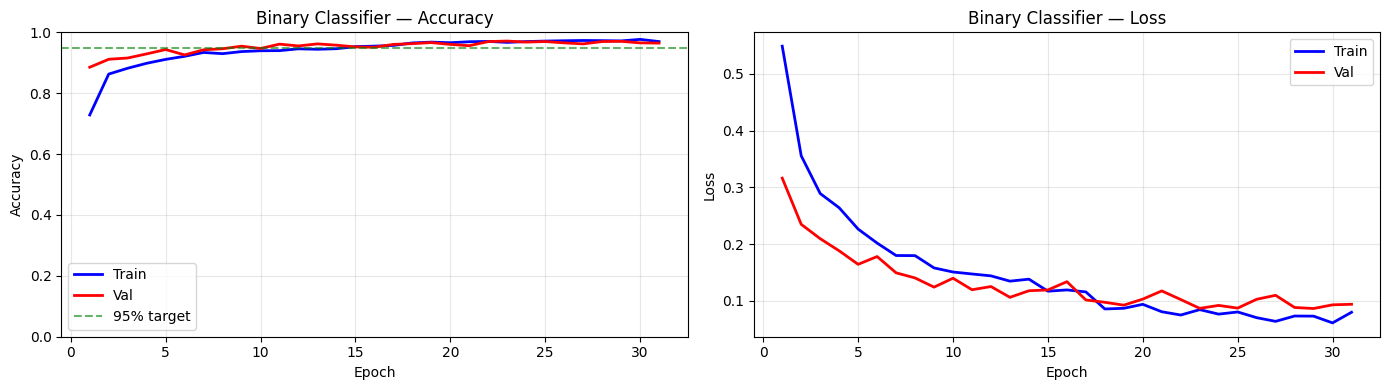

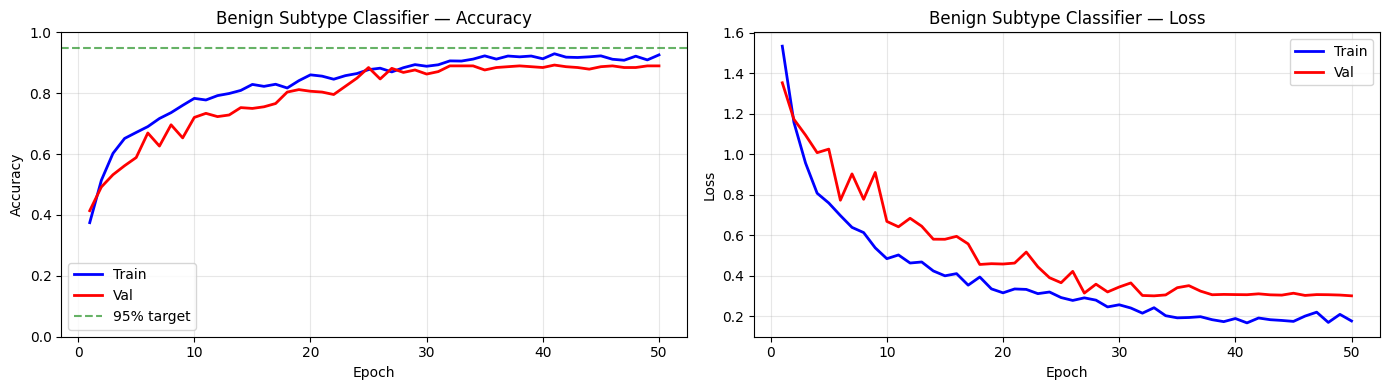

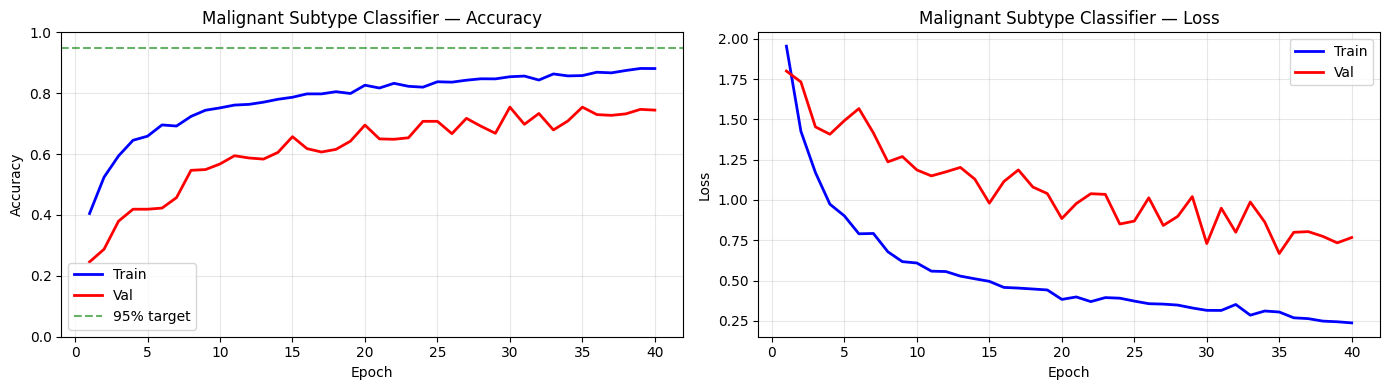

In [13]:
def plot_history(history, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

    epochs_ran = range(1, len(history.history['accuracy']) + 1)

    ax1.plot(epochs_ran, history.history['accuracy'],     'b-', label='Train', linewidth=2)
    ax1.plot(epochs_ran, history.history['val_accuracy'], 'r-', label='Val',   linewidth=2)
    ax1.axhline(y=0.95, color='green', linestyle='--', alpha=0.6, label='95% target')
    ax1.set_title(f'{title} — Accuracy')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
    ax1.set_ylim([0, 1]); ax1.legend(); ax1.grid(True, alpha=0.3)

    ax2.plot(epochs_ran, history.history['loss'],     'b-', label='Train', linewidth=2)
    ax2.plot(epochs_ran, history.history['val_loss'], 'r-', label='Val',   linewidth=2)
    ax2.set_title(f'{title} — Loss')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
    ax2.legend(); ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{title.lower().replace(" ", "_")}_curves.png',
                dpi=100, bbox_inches='tight')
    plt.show()


plot_history(history_bin, 'Binary Classifier')
plot_history(history_ben, 'Benign Subtype Classifier')
plot_history(history_mal, 'Malignant Subtype Classifier')


## 12. Evaluation & Confusion Matrix


=== Binary Classifier ===
              precision    recall  f1-score   support

      Benign       0.94      0.95      0.95       372
   Malignant       0.98      0.97      0.98       815

    accuracy                           0.97      1187
   macro avg       0.96      0.96      0.96      1187
weighted avg       0.97      0.97      0.97      1187



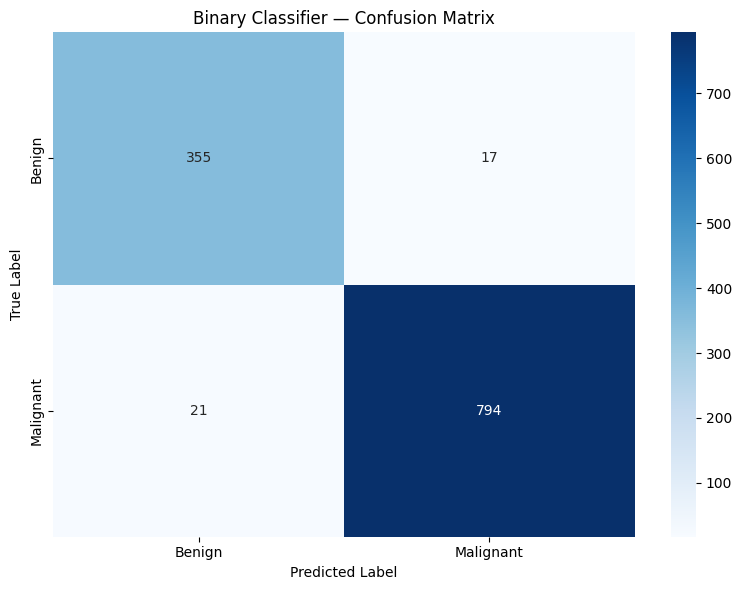


=== Benign Subtype Classifier ===
                 precision    recall  f1-score   support

       Adenosis       0.79      0.97      0.87        67
   Fibroadenoma       0.94      0.64      0.76       152
Phyllodes Tumor       0.69      0.91      0.78        68
Tubular Adenoma       0.85      0.96      0.90        85

       accuracy                           0.82       372
      macro avg       0.82      0.87      0.83       372
   weighted avg       0.85      0.82      0.82       372



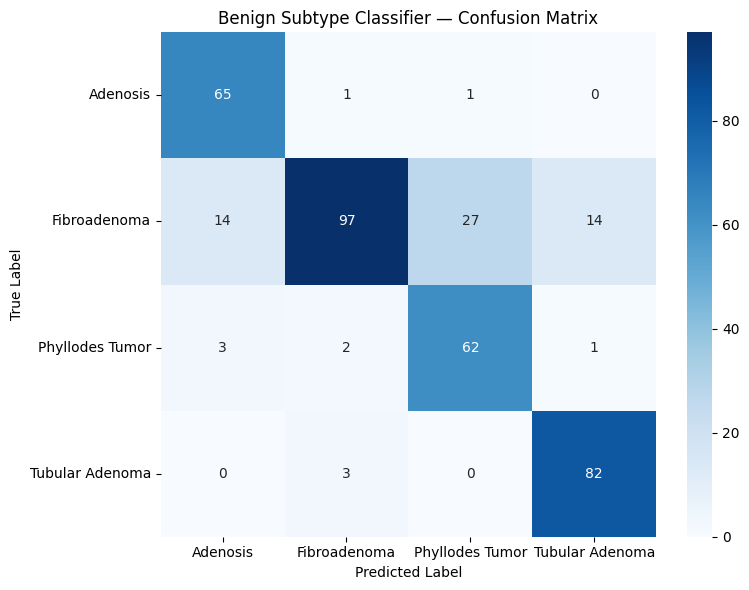


=== Malignant Subtype Classifier ===
                     precision    recall  f1-score   support

   Ductal Carcinoma       0.97      0.66      0.79       518
  Lobular Carcinoma       0.53      0.88      0.66        94
 Mucinous Carcinoma       0.64      0.92      0.76       119
Papillary Carcinoma       0.61      0.95      0.74        84

           accuracy                           0.76       815
          macro avg       0.69      0.86      0.74       815
       weighted avg       0.83      0.76      0.76       815



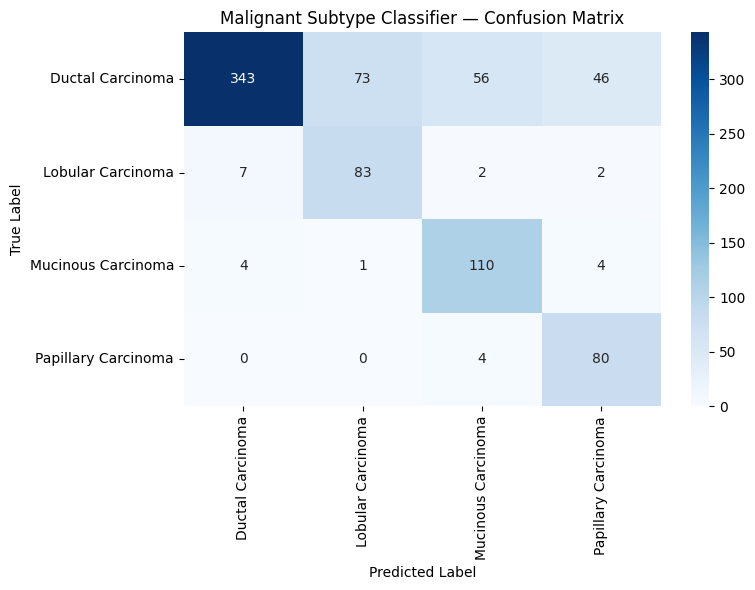


FINAL TEST SET RESULTS
  Binary Classifier        : 96.8%
  Benign Subtype (4-class) : 82.3%
  Malignant Subtype        : 75.6%


In [14]:
# Load best saved models (ModelCheckpoint saved them during training)
binary_model_best    = load_model('binary_model.h5')
benign_model_best    = load_model('benign_subtype_model.h5')
malignant_model_best = load_model('malignant_subtype_model.h5')


def evaluate_model(model, test_flow, test_df, label_names, title, binary=False):
    test_flow.reset()
    preds  = model.predict(test_flow, verbose=0)
    y_pred = (preds.flatten() > 0.5).astype(int) if binary else np.argmax(preds, axis=1)
    y_true = test_df['label'].values[:len(y_pred)]

    print(f'\n=== {title} ===')
    print(classification_report(y_true, y_pred, target_names=label_names))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_names, yticklabels=label_names)
    plt.title(f'{title} — Confusion Matrix')
    plt.ylabel('True Label'); plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig(f'{title.lower().replace(" ", "_")}_confusion.png',
                dpi=100, bbox_inches='tight')
    plt.show()

    return accuracy_score(y_true, y_pred)


acc_bin = evaluate_model(
    binary_model_best, test_bin_flow, test_bin,
    ['Benign', 'Malignant'], 'Binary Classifier', binary=True)

acc_ben = evaluate_model(
    benign_model_best, test_be_flow, test_be,
    [BENIGN_NAMES[i] for i in range(4)], 'Benign Subtype Classifier')

acc_mal = evaluate_model(
    malignant_model_best, test_ma_flow, test_ma,
    [MALIGNANT_NAMES[i] for i in range(4)], 'Malignant Subtype Classifier')

print('\n' + '=' * 60)
print('FINAL TEST SET RESULTS')
print('=' * 60)
print(f'  Binary Classifier        : {acc_bin:.1%}')
print(f'  Benign Subtype (4-class) : {acc_ben:.1%}')
print(f'  Malignant Subtype        : {acc_mal:.1%}')


## 13. End-to-End Inference Pipeline

In [15]:
from scipy.stats import entropy as scipy_entropy

BENIGN_IDX_TO_NAME    = {v: k for k, v in BENIGN_SUBTYPES.items()}
MALIGNANT_IDX_TO_NAME = {v: k for k, v in MALIGNANT_SUBTYPES.items()}


def _uncertainty_level(probs: np.ndarray) -> str:
    """Classify prediction uncertainty from the softmax distribution."""
    top1_margin = np.max(probs) - np.sort(probs)[-2]
    if top1_margin >= 0.40:
        return 'low'
    elif top1_margin >= 0.20:
        return 'moderate'
    else:
        return 'high'


def predict_image(img_path: str) -> dict:
    """Full two-stage pipeline on a single image.
    Returns structured dict for Mistral-7B report generation.
    """
    img       = load_and_preprocess(img_path)
    img_batch = np.expand_dims(img, 0)

    # Stage 1: Binary
    mal_prob    = float(binary_model_best.predict(img_batch, verbose=0)[0][0])
    ben_prob    = round(1.0 - mal_prob, 4)
    mal_prob    = round(mal_prob, 4)
    binary_pred = 'malignant' if mal_prob > 0.5 else 'benign'
    binary_conf = mal_prob if binary_pred == 'malignant' else ben_prob

    # Stage 2: Subtype
    if binary_pred == 'benign':
        subtype_probs_raw = benign_model_best.predict(img_batch, verbose=0)[0]
        idx_to_name       = BENIGN_IDX_TO_NAME
    else:
        subtype_probs_raw = malignant_model_best.predict(img_batch, verbose=0)[0]
        idx_to_name       = MALIGNANT_IDX_TO_NAME

    top_idx      = int(np.argmax(subtype_probs_raw))
    subtype_name = idx_to_name[top_idx]
    subtype_conf = round(float(subtype_probs_raw[top_idx]), 4)

    differential = {
        idx_to_name[i]: round(float(p), 4)
        for i, p in sorted(enumerate(subtype_probs_raw), key=lambda x: -x[1])
    }

    return {
        'binary': {
            'prediction':    binary_pred,
            'confidence':    round(binary_conf, 4),
            'probabilities': {'benign': ben_prob, 'malignant': mal_prob},
        },
        'subtype': {
            'prediction':  subtype_name,
            'confidence':  subtype_conf,
            'uncertainty': _uncertainty_level(subtype_probs_raw),
            'differential': differential,
        },
        'display_label': f"{binary_pred.capitalize()}: {subtype_name.replace('_', ' ').title()}",
        'image_path':    img_path,
    }


# Demo on a sample image
sample_path = df.sample(1, random_state=0)['path'].values[0]
result      = predict_image(sample_path)
print('Structured prediction result:')
print(json.dumps(result, indent=2))


Structured prediction result:
{
  "binary": {
    "prediction": "malignant",
    "confidence": 1.0,
    "probabilities": {
      "benign": 0.0,
      "malignant": 1.0
    }
  },
  "subtype": {
    "prediction": "ductal_carcinoma",
    "confidence": 0.9983,
    "uncertainty": "low",
    "differential": {
      "ductal_carcinoma": 0.9983,
      "papillary_carcinoma": 0.0013,
      "lobular_carcinoma": 0.0004,
      "mucinous_carcinoma": 0.0
    }
  },
  "display_label": "Malignant: Ductal Carcinoma",
  "image_path": "/kaggle/input/datasets/ambarish/breakhis/BreaKHis_v1/BreaKHis_v1/histology_slides/breast/malignant/SOB/ductal_carcinoma/SOB_M_DC_14-2773/100X/SOB_M_DC-14-2773-100-006.png"
}


## 14. Save Models & Label Files

In [16]:
# ── Save Keras models ──────────────────────────────────────────────────────
binary_model_best.save('binary_model.h5')
benign_model_best.save('benign_subtype_model.h5')
malignant_model_best.save('malignant_subtype_model.h5')

# ── Save class label .txt files (for Silva workflow) ───────────────────────
with open('binary_classes.txt', 'w') as f:
    f.write('benign\nmalignant\n')

with open('benign_classes.txt', 'w') as f:
    for name in ['Adenosis', 'Fibroadenoma', 'Phyllodes Tumor', 'Tubular Adenoma']:
        f.write(name + '\n')

with open('malignant_classes.txt', 'w') as f:
    for name in ['Ductal Carcinoma', 'Lobular Carcinoma',
                 'Mucinous Carcinoma', 'Papillary Carcinoma']:
        f.write(name + '\n')

# ── Save label maps JSON (for Notebook 2) ─────────────────────────────────
label_maps = {
    'binary':             {'benign': 0, 'malignant': 1},
    'benign_subtypes':    BENIGN_SUBTYPES,
    'malignant_subtypes': MALIGNANT_SUBTYPES,
}
with open('label_maps.json', 'w') as f:
    json.dump(label_maps, f, indent=2)

# ── Export predictions for Notebook 2 ─────────────────────────────────────
EXPORT_SAMPLES       = 8
sample_paths         = df.sample(EXPORT_SAMPLES, random_state=SEED)['path'].tolist()
exported_predictions = [predict_image(p) for p in sample_paths]
with open('cnn_predictions.json', 'w') as f:
    json.dump(exported_predictions, f, indent=2)

# ── Final summary ──────────────────────────────────────────────────────────
print('\n' + '=' * 60)
print('ALL FILES SAVED — READY TO DOWNLOAD')
print('=' * 60)
print(f'\n  Model files:')
print(f'    ✓ binary_model.h5')
print(f'    ✓ benign_subtype_model.h5')
print(f'    ✓ malignant_subtype_model.h5')
print(f'\n  Label files (for Silva workflow):')
print(f'    ✓ binary_classes.txt')
print(f'    ✓ benign_classes.txt')
print(f'    ✓ malignant_classes.txt')
print(f'\n  Metadata (for Notebook 2):')
print(f'    ✓ label_maps.json')
print(f'    ✓ cnn_predictions.json')
print(f'\n  Best val accuracies:')
print(f'    Binary:            {max(history_bin.history["val_accuracy"]):.1%}')
print(f'    Benign subtype:    {max(history_ben.history["val_accuracy"]):.1%}')
print(f'    Malignant subtype: {max(history_mal.history["val_accuracy"]):.1%}')
print('\nNext: Download all files → add to Silva workflow models/ folder.')



ALL FILES SAVED — READY TO DOWNLOAD

  Model files:
    ✓ binary_model.h5
    ✓ benign_subtype_model.h5
    ✓ malignant_subtype_model.h5

  Label files (for Silva workflow):
    ✓ binary_classes.txt
    ✓ benign_classes.txt
    ✓ malignant_classes.txt

  Metadata (for Notebook 2):
    ✓ label_maps.json
    ✓ cnn_predictions.json

  Best val accuracies:
    Binary:            97.1%
    Benign subtype:    89.2%
    Malignant subtype: 75.4%

Next: Download all files → add to Silva workflow models/ folder.
